In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# -- 1. Import Libraries and Constants --
import torch
import pandas as pd
import os
from constants import INPUT_DIM, LATENT_DIM, EPOCHS, LR, DEVICE, NUM_SAMPLES, NUM_CLASSES
from data_handling import data_loading_all_parquet, data_prep_conditional, save_data
# ## Architecture Upgrade: Import the new ConvolutionalCVAE ##
from VAE_utils import ConvolutionalCVAE, train_cvae, generate_synthetic_conditional

In [3]:
# Create directory for results if it doesn't exist
os.makedirs("../Results/CVAE_generated", exist_ok=True)

In [4]:
# -- 2. Define Crop Names and Load All Data --
# This list defines the order and the integer labels (0 to 5)
CROP_NAMES = [
    'capsicum',          # label 0
    'chilli',            # label 1
    'mulberry',          # label 2
    'potato',            # label 3
    'tomato_healthy',    # label 4
    'tomato_unhealthy'   # label 5
]

# Load and combine all crop data into a single dataframe
df_all_crops = data_loading_all_parquet(CROP_NAMES)

# Get the original band names for saving later
original_bands = df_all_crops.columns.drop('label')

Loaded capsicum (label 0). Shape: (60, 944)
Loaded chilli (label 1). Shape: (100, 944)
Loaded mulberry (label 2). Shape: (120, 944)
Loaded potato (label 3). Shape: (616, 944)
Loaded tomato_healthy (label 4). Shape: (2138, 944)
Loaded tomato_unhealthy (label 5). Shape: (119, 944)

Total combined DataFrame shape: (3153, 944)
Value counts for labels:
 4    2138
3     616
2     120
5     119
1     100
0      60
Name: label, dtype: int64


In [5]:
# -- 3. Prepare Data for PyTorch --
scaler, train_loader, test_loader = data_prep_conditional(df_all_crops)
print(f"\nData prepared. Training on {DEVICE}.")


Data prepared. Training on cuda:0.


In [6]:
# -- 4. Initialize and Train the Convolutional CVAE Model --
# ## Architecture Upgrade: Initialize the new model ##
cvae_model = ConvolutionalCVAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES)

import time
start_time = time.time()
# The same training function works perfectly with the new model
trained_model = train_cvae(
    model=cvae_model,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=EPOCHS,
    lr=LR,
    device=DEVICE,
    patience=30
)

total_time = time.time() - start_time
print(f"Total training time: {total_time/60:.2f} minutes")


Starting training for ConvolutionalCVAE...


Epoch 1/5000 | Train Loss: 0.0084 | Val Loss: 1110.0370
  -> New best model saved with validation loss: 1110.0370


Epoch 2/5000 | Train Loss: 0.4935 | Val Loss: 37.4251
  -> New best model saved with validation loss: 37.4251


Epoch 3/5000 | Train Loss: 0.0307 | Val Loss: 43.3047
  -> No improvement. Patience: 1/30


Epoch 4/5000 | Train Loss: 0.0220 | Val Loss: 7.3716
  -> New best model saved with validation loss: 7.3716


...

Epoch 173/5000 | Train Loss: 0.0072 | Val Loss: 0.0090
  -> No improvement. Patience: 26/30


Epoch 174/5000 | Train Loss: 0.0072 | Val Loss: 0.0090
  -> No improvement. Patience: 27/30


Epoch 175/5000 | Train Loss: 0.0072 | Val Loss: 0.0090
  -> No improvement. Patience: 28/30


Epoch 176/5000 | Train Loss: 0.0071 | Val Loss: 0.0090
  -> No improvement. Patience: 29/30


Epoch 177/5000 | Train Loss: 0.0071 | Val Loss: 0.0090
  -> No improvement. Patience: 30/30
Early stopping triggered at epoch 177. Restoring best model.
Training finished.
Total training time: 1.13 minutes


In [7]:
# -- 5. Generate and Save Synthetic Data for Each Crop --
print("\n--- Generating Synthetic Data for Each Crop ---")

for i, crop_name in enumerate(CROP_NAMES):
    synthetic_data = generate_synthetic_conditional(
        model=trained_model,
        scaler=scaler,
        num_samples=NUM_SAMPLES,
        label_to_generate=i,
        latent_dim=LATENT_DIM,
        device=DEVICE
    )
    
    save_data(
        synthetic_data=synthetic_data,
        crop_name=crop_name,
        bands=original_bands,
        label_id=i
    )

print("\nConvolutional CVAE process complete. All synthetic data saved.")


--- Generating Synthetic Data for Each Crop ---
Saved 2000 synthetic samples for capsicum (label 0)
Saved 2000 synthetic samples for chilli (label 1)
Saved 2000 synthetic samples for mulberry (label 2)
Saved 2000 synthetic samples for potato (label 3)
Saved 2000 synthetic samples for tomato_healthy (label 4)
Saved 2000 synthetic samples for tomato_unhealthy (label 5)

Convolutional CVAE process complete. All synthetic data saved.


Successfully generated 'CNN_CVAE_Architecture.pdf'


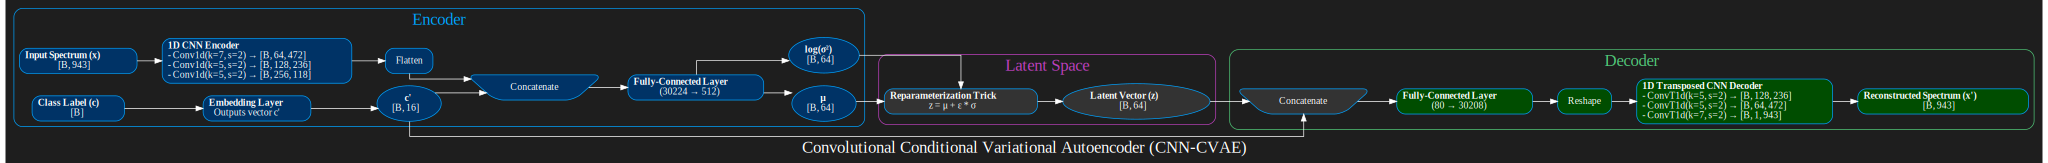

In [8]:
# generate_architecture_diagram.py
# This script is designed to be run in a Jupyter Notebook cell.

from graphviz import Digraph

# --- Create the main graph object ---
# This object will hold all the components of our diagram.
dot = Digraph(comment='Convolutional CVAE Architecture')
dot.attr('graph',
         rankdir='LR',          # Layout from Left to Right
         splines='ortho',       # Use orthogonal lines for a cleaner look
         bgcolor='#1E1E1E',     # Dark background for a modern feel
         label='Convolutional Conditional Variational Autoencoder (CNN-CVAE)',
         fontcolor='white',
         fontsize='24')

# --- Define default styles for nodes and edges ---
dot.attr('node',
         shape='box',
         style='rounded,filled',
         fillcolor='#333333',
         fontcolor='white',
         color='#00A2FF') # Default border color (blue)

dot.attr('edge', color='white')

# --- 1. ENCODER SUBGRAPH (Blue Theme) ---
# 'with dot.subgraph' creates a boxed area for organization.
with dot.subgraph(name='cluster_encoder') as c:
    c.attr(label='Encoder', fontcolor='#00A2FF', color='#00A2FF', style='rounded')
    c.attr('node', fillcolor='#003366') # Nodes within this subgraph are dark blue

    # Input nodes
    c.node('input_x', label='<<b>Input Spectrum (x)</b><br/>[B, 943]>')
    c.node('input_c', label='<<b>Class Label (c)</b><br/>[B]>')

    # Label embedding path
    c.node('embedding', label='<<b>Embedding Layer</b><br/>Outputs vector c\'>')
    c.node('c_prime', label='<<b>c\'</b><br/>[B, 16]>', shape='ellipse')
    c.edge('input_c', 'embedding')
    c.edge('embedding', 'c_prime')

    # Main data path using 1D Convolutions
    # HTML-like labels allow for rich formatting like bold text and line breaks.
    c.node('cnn_encoder', label='''<
<B>1D CNN Encoder</B><BR ALIGN="LEFT"/>
- Conv1d(k=7, s=2) → [B, 64, 472]<BR ALIGN="LEFT"/>
- Conv1d(k=5, s=2) → [B, 128, 236]<BR ALIGN="LEFT"/>
- Conv1d(k=5, s=2) → [B, 256, 118]<BR ALIGN="LEFT"/>
>''')
    c.node('flatten', 'Flatten')
    c.node('concat_enc', 'Concatenate', shape='invtrapezium')
    c.node('fc_enc', label='<<b>Fully-Connected Layer</b><br/>(30224 → 512)>')
    c.node('mu', label='<<b>μ</b><br/>[B, 64]>', shape='ellipse')
    c.node('log_var', label='<<b>log(σ²)</b><br/>[B, 64]>', shape='ellipse')

    # Connect the nodes in the encoder path
    c.edge('input_x', 'cnn_encoder')
    c.edge('cnn_encoder', 'flatten')
    c.edge('flatten', 'concat_enc')
    c.edge('c_prime', 'concat_enc') # Connect the embedded label to the main path
    c.edge('concat_enc', 'fc_enc')
    c.edge('fc_enc', 'mu', headport='w')
    c.edge('fc_enc', 'log_var', headport='w')


# --- 2. LATENT SPACE SUBGRAPH (Purple Theme) ---
with dot.subgraph(name='cluster_latent') as c:
    c.attr(label='Latent Space', fontcolor='#BF40BF', color='#BF40BF', style='rounded')
    c.attr('node', fillcolor='#4B0082') # Dark purple nodes

    c.node('reparam', label='<<b>Reparameterization Trick</b><br/>z = μ + ε * σ>')
    c.node('z', label='<<b>Latent Vector (z)</b><br/>[B, 64]>', shape='ellipse')

    # Edges are defined outside the subgraph to cross cluster boundaries
    dot.edge('mu', 'reparam', lhead='cluster_latent')
    dot.edge('log_var', 'reparam')
    dot.edge('reparam', 'z')


# --- 3. DECODER SUBGRAPH (Green Theme) ---
with dot.subgraph(name='cluster_decoder') as c:
    c.attr(label='Decoder', fontcolor='#50C878', color='#50C878', style='rounded')
    c.attr('node', fillcolor='#004d00') # Dark green nodes

    c.node('concat_dec', 'Concatenate', shape='invtrapezium')
    c.node('fc_dec', label='<<b>Fully-Connected Layer</b><br/>(80 → 30208)>')
    c.node('reshape', 'Reshape')
    c.node('cnn_decoder', label='''<
<B>1D Transposed CNN Decoder</B><BR ALIGN="LEFT"/>
- ConvT1d(k=5, s=2) → [B, 128, 236]<BR ALIGN="LEFT"/>
- ConvT1d(k=5, s=2) → [B, 64, 472]<BR ALIGN="LEFT"/>
- ConvT1d(k=7, s=2) → [B, 1, 943]<BR ALIGN="LEFT"/>
>''')
    c.node('output_x', label='<<b>Reconstructed Spectrum (x\')</b><br/>[B, 943]>')

    # Connect the nodes in the decoder path
    c.edge('concat_dec', 'fc_dec')
    c.edge('fc_dec', 'reshape')
    c.edge('reshape', 'cnn_decoder')
    c.edge('cnn_decoder', 'output_x')

    # Connect nodes from other subgraphs
    dot.edge('z', 'concat_dec', lhead='cluster_decoder')
    # 'constraint=false' helps the layout engine make cleaner lines
    dot.edge('c_prime', 'concat_dec', constraint='false')

# --- Render and Save the Diagram ---
# This will save the diagram as a high-quality PDF in the same directory as your notebook.
dot.render('CNN_CVAE_Architecture', format='pdf', cleanup=True)
print("Successfully generated 'CNN_CVAE_Architecture.pdf'")

# --- Display the diagram directly in the Jupyter Notebook output ---
# Placing the 'dot' object as the last line in a cell tells Jupyter to render it.
dot


Successfully generated 'CNN_CVAE_Architecture_Vertical.pdf'


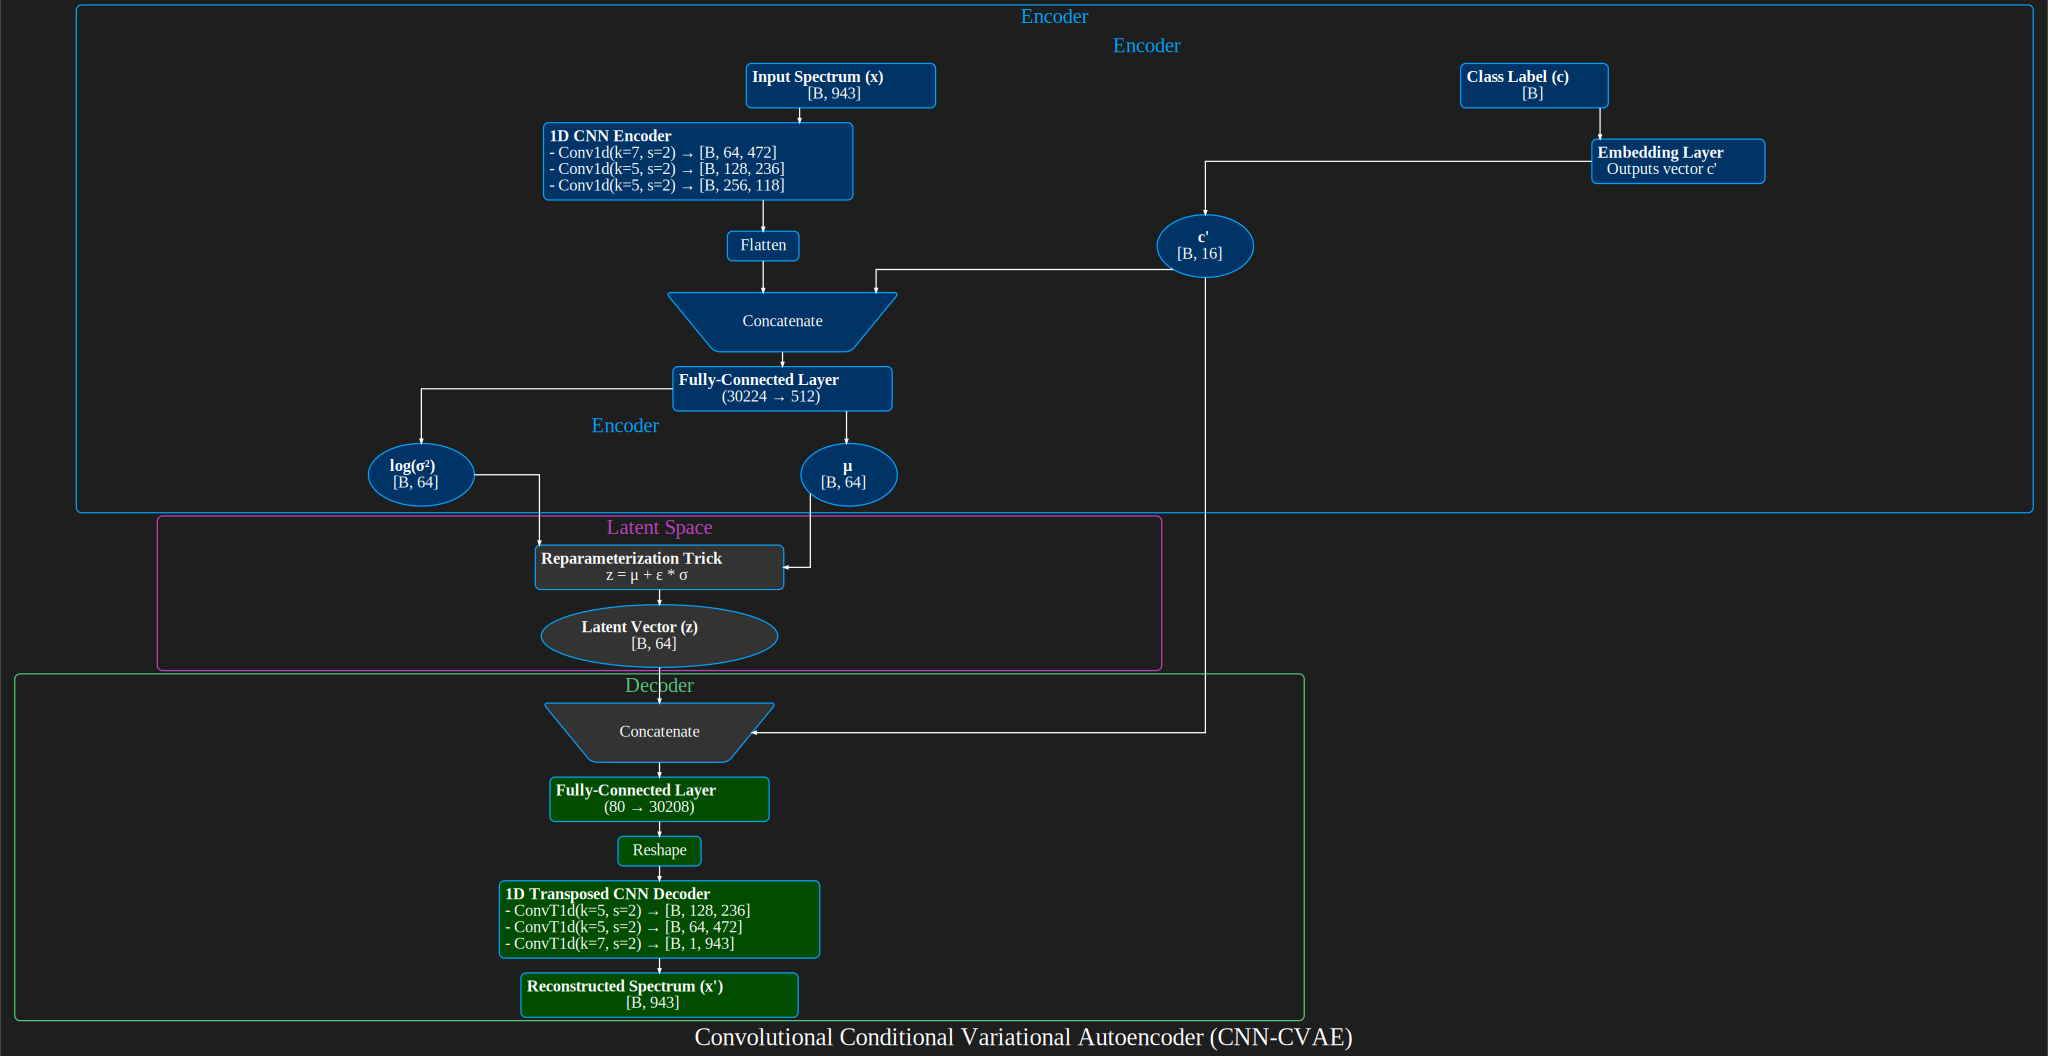

In [9]:
# generate_architecture_diagram.py
# This script is designed to be run in a Jupyter Notebook cell.

from graphviz import Digraph

# --- DIAGRAM CONTROLS ---
# You can easily adjust all visual properties for the diagram here.
main_title_fontsize = '60'
subgraph_title_fontsize = '50'
node_fontsize = '40'
node_penwidth = '3' # ADDED: Controls the thickness of the bounding box lines.

# --- Create the main graph object ---
# This object will hold all the components of our diagram.
dot = Digraph(comment='Convolutional CVAE Architecture')
dot.attr('graph',
         rankdir='TB',          # Layout from Top to Bottom
         ratio='0.5',           # Suggest a 1:2 height-to-width aspect ratio
         splines='ortho',       # Use orthogonal lines for a cleaner look
         bgcolor='#1E1E1E',     # Dark background for a modern feel
         label='Convolutional Conditional Variational Autoencoder (CNN-CVAE)',
         fontcolor='white',
         fontsize=main_title_fontsize) # UPDATED

# --- Define default styles for nodes and edges ---
dot.attr('node',
         shape='box',
         style='rounded,filled',
         fillcolor='#333333',
         fontcolor='white',
         fontsize=node_fontsize, # UPDATED
         color='#00A2FF', # Default border color (blue)
         margin='0.2', # Increased margin slightly for larger fonts
         penwidth=node_penwidth) # ADDED

dot.attr('edge', color='white', penwidth=node_penwidth) # Also make connector lines thicker

# --- 1. ENCODER SUBGRAPH (Blue Theme) ---
# 'with dot.subgraph' creates a boxed area for organization.
with dot.subgraph(name='cluster_encoder') as c:
    c.attr(label='Encoder', fontcolor='#00A2FF', color='#00A2FF', style='rounded', fontsize=subgraph_title_fontsize, penwidth=node_penwidth) # UPDATED
    c.attr('node', fillcolor='#003366') # Nodes within this subgraph are dark blue

    # Input nodes
    with c.subgraph(name='cluster_inputs') as c_inputs:
        c_inputs.attr(rank='same', color='transparent') # Keep inputs on the same level
        c_inputs.node('input_x', label='<<b>Input Spectrum (x)</b><br/>[B, 943]>')
        c_inputs.node('input_c', label='<<b>Class Label (c)</b><br/>[B]>')

    # Label embedding path
    c.node('embedding', label='<<b>Embedding Layer</b><br/>Outputs vector c\'>')
    c.node('c_prime', label='<<b>c\'</b><br/>[B, 16]>', shape='ellipse')
    c.edge('input_c', 'embedding')
    c.edge('embedding', 'c_prime')

    # Main data path using 1D Convolutions
    c.node('cnn_encoder', label='''<
<B>1D CNN Encoder</B><BR ALIGN="LEFT"/>
- Conv1d(k=7, s=2) → [B, 64, 472]<BR ALIGN="LEFT"/>
- Conv1d(k=5, s=2) → [B, 128, 236]<BR ALIGN="LEFT"/>
- Conv1d(k=5, s=2) → [B, 256, 118]<BR ALIGN="LEFT"/>
>''')
    c.node('flatten', 'Flatten')
    c.node('concat_enc', 'Concatenate', shape='invtrapezium')
    c.node('fc_enc', label='<<b>Fully-Connected Layer</b><br/>(30224 → 512)>')
    
    with c.subgraph(name='cluster_params') as c_params:
        c_params.attr(rank='same', color='transparent')
        c_params.node('mu', label='<<b>μ</b><br/>[B, 64]>', shape='ellipse')
        c_params.node('log_var', label='<<b>log(σ²)</b><br/>[B, 64]>', shape='ellipse')

    # Connect the nodes in the encoder path
    c.edge('input_x', 'cnn_encoder')
    c.edge('cnn_encoder', 'flatten')
    c.edge('flatten', 'concat_enc')
    c.edge('c_prime', 'concat_enc') # Connect the embedded label to the main path
    c.edge('concat_enc', 'fc_enc')
    c.edge('fc_enc', 'mu')
    c.edge('fc_enc', 'log_var')


# --- 2. LATENT SPACE SUBGRAPH (Purple Theme) ---
with dot.subgraph(name='cluster_latent') as c:
    c.attr(label='Latent Space', fontcolor='#BF40BF', color='#BF40BF', style='rounded', fontsize=subgraph_title_fontsize, penwidth=node_penwidth) # UPDATED
    c.attr('node', fillcolor='#4B0082') # Dark purple nodes

    c.node('reparam', label='<<b>Reparameterization Trick</b><br/>z = μ + ε * σ>')
    c.node('z', label='<<b>Latent Vector (z)</b><br/>[B, 64]>', shape='ellipse')

    # Edges are defined outside the subgraph to cross cluster boundaries
    dot.edge('mu', 'reparam')
    dot.edge('log_var', 'reparam')
    dot.edge('reparam', 'z')


# --- 3. DECODER SUBGRAPH (Green Theme) ---
with dot.subgraph(name='cluster_decoder') as c:
    c.attr(label='Decoder', fontcolor='#50C878', color='#50C878', style='rounded', fontsize=subgraph_title_fontsize, penwidth=node_penwidth) # UPDATED
    c.attr('node', fillcolor='#004d00') # Dark green nodes

    c.node('concat_dec', 'Concatenate', shape='invtrapezium')
    c.node('fc_dec', label='<<b>Fully-Connected Layer</b><br/>(80 → 30208)>')
    c.node('reshape', 'Reshape')
    c.node('cnn_decoder', label='''<
<B>1D Transposed CNN Decoder</B><BR ALIGN="LEFT"/>
- ConvT1d(k=5, s=2) → [B, 128, 236]<BR ALIGN="LEFT"/>
- ConvT1d(k=5, s=2) → [B, 64, 472]<BR ALIGN="LEFT"/>
- ConvT1d(k=7, s=2) → [B, 1, 943]<BR ALIGN="LEFT"/>
>''')
    c.node('output_x', label='<<b>Reconstructed Spectrum (x\')</b><br/>[B, 943]>')

    # Connect the nodes in the decoder path
    c.edge('concat_dec', 'fc_dec')
    c.edge('fc_dec', 'reshape')
    c.edge('reshape', 'cnn_decoder')
    c.edge('cnn_decoder', 'output_x')

    # Connect nodes from other subgraphs
    dot.edge('z', 'concat_dec')
    # 'constraint=false' helps the layout engine make cleaner lines
    dot.edge('c_prime', 'concat_dec', constraint='false')

# --- Render and Save the Diagram ---
# This will save the diagram as a high-quality PDF in the same directory as your notebook.
dot.render('CNN_CVAE_Architecture_Vertical', format='pdf', cleanup=True)
print("Successfully generated 'CNN_CVAE_Architecture_Vertical.pdf'")

# --- Display the diagram directly in the Jupyter Notebook output ---
# Placing the 'dot' object as the last line in a cell tells Jupyter to render it.
dot


In [11]:
for module in cvae_model.modules():
    print(f"Layer Type: {type(module)}")


Layer Type: <class 'VAE_utils.ConvolutionalCVAE'>
Layer Type: <class 'torch.nn.modules.sparse.Embedding'>
Layer Type: <class 'torch.nn.modules.container.Sequential'>
Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Type: <class 'torch.nn.modules.container.Sequential'>
Layer Type: <class 'torch.nn.modules.linear.Linear'>
Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Type: <class 'torch.nn.modules.linear.Linear'>
Layer Type: <class 'torch.nn.modules.linear.Linear'>
Layer Type: <class 'torch.nn.modules.container.Sequential'>

In [10]:
for name, module in cvae_model.named_modules():
    print(f"Layer Name: {name}, Layer Type: {type(module)}")


Layer Name: , Layer Type: <class 'VAE_utils.ConvolutionalCVAE'>
Layer Name: label_embedding, Layer Type: <class 'torch.nn.modules.sparse.Embedding'>
Layer Name: encoder_conv, Layer Type: <class 'torch.nn.modules.container.Sequential'>
Layer Name: encoder_conv.0, Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Name: encoder_conv.1, Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Name: encoder_conv.2, Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Name: encoder_conv.3, Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Name: encoder_conv.4, Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Name: encoder_conv.5, Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Name: encoder_conv.6, Layer Type: <class 'torch.nn.modules.conv.Conv1d'>
Layer Name: encoder_conv.7, Layer Type: <class 'torch.nn.modules.batchnorm.BatchNorm1d'>
Layer Name: encoder_conv.8, Layer Type: <class 'torch.nn.modules.activation.ReLU'>
Layer Name: 

In [9]:
from torchinfo import summary


cvae_model = ConvolutionalCVAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES)
print(cvae_model)

ConvolutionalCVAE(
  (label_embedding): Embedding(6, 16)
  (encoder_conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(128, 256, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=30224, out_features=512, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=512, out_features=64, bias=True)
  (fc_log_var): Linear(in_features=512, out_features=64, bias=True)
  (decoder_fc): Sequential(
    (0): Linear(in_features=80, out_features=30208, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(

In [14]:
# Parameter count

total_params = sum(p.numel() for p in cvae_model.parameters())
trainable_params = sum(p.numel() for p in cvae_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 18,400,225
Trainable parameters: 18,400,225
